In this notebook, the precision performance of all the models will be extracted with some basic and easy plots. This will help interpret the results and arrive to the final conclusions (which will be developed in Chapter 4, in the report). All the plots will be saves inside the $\texttt{images/}$ folder.

# Imports

In [1]:
import numpy as np
import pandas as pd

import os

import matplotlib.pyplot as plt
import seaborn as sns

from utils import compare_models, compare_test_size, roc_pr_combined

In [2]:
path_1 = "results/4.supervised_ml.csv"
df_1 = pd.read_csv(path_1)

path_2 = "results/5.nn_rf.csv"
df_2 = pd.read_csv(path_2)

path_3 = "results/6.contrastive.csv"
df_3 = pd.read_csv(path_3)

path_4 = "results/7.contrastive_gating.csv"
df_4 = pd.read_csv(path_4)

path_5 = "results/7.final_weights.csv"
df_5 = pd.read_csv(path_5)

path_6 = "results/8.contrastive_after_gating.csv"
df_6 = pd.read_csv(path_6)

path_7 = "results/6.synthetic_contrastive.csv"
df_7 = pd.read_csv(path_7)

path_8 = "results/8.synthetic_contrastive_after_gating.csv"
df_8 = pd.read_csv(path_8)

# Supervised models

Using $\texttt{4.supervised\_ml}$.

In [3]:
df_1.head(3)

,model,random_state,test_size,ROC-AUC,PR-AUC,Accuracy
0,Random Forest,42,0.3,0.634057,0.421162,0.754237
1,Logistic Regression,42,0.3,0.552886,0.300377,0.550847
2,Gradient Boosting,42,0.3,0.508330,0.306302,0.703390


## Dataset

In [4]:
summary4 = (
    df_1
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary4

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Gradient Boosting,0.20,0.539254,0.301254,0.699367
1,Gradient Boosting,0.30,0.550852,0.307935,0.701271
2,Gradient Boosting,0.33,0.554887,0.299297,0.695192
3,Gradient Boosting,0.50,0.541649,0.300953,0.701531
4,Gradient Boosting,0.66,0.547989,0.280373,0.692085
5,Gradient Boosting,0.75,0.552288,0.293135,0.704507
6,Gradient Boosting,0.80,0.547330,0.288616,0.695687
7,Gradient Boosting,0.90,0.510590,0.263051,0.669034
8,Logistic Regression,0.20,0.575658,0.325313,0.585443
9,Logistic Regression,0.30,0.591680,0.318563,0.590042


## ROC-AUC

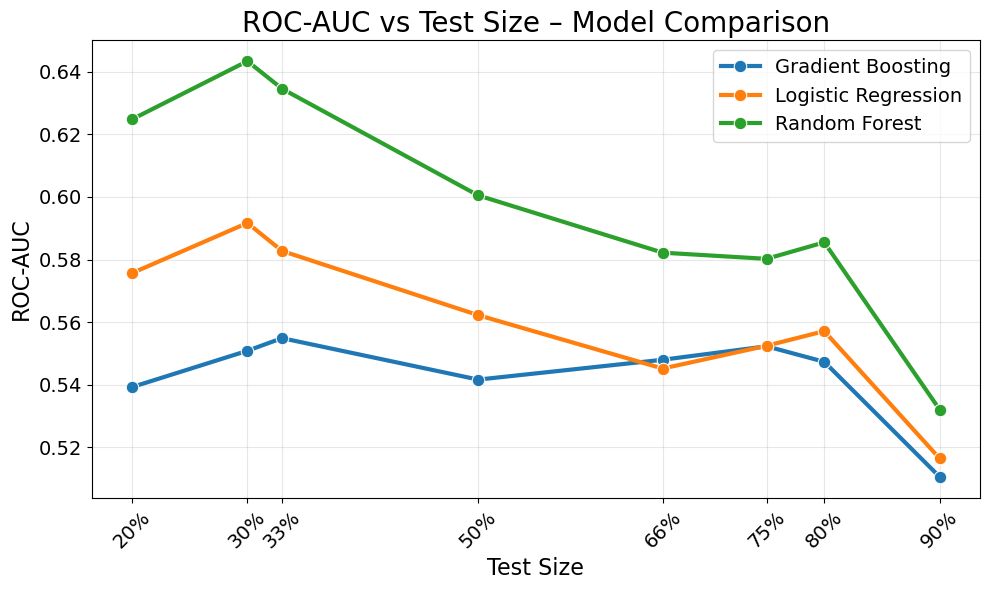

In [5]:
fig = compare_models(summary4, "ROC-AUC")
fig

fig.savefig("images/4.supervised_roc_comparison.png", dpi=300, bbox_inches="tight")

## PR-AUC

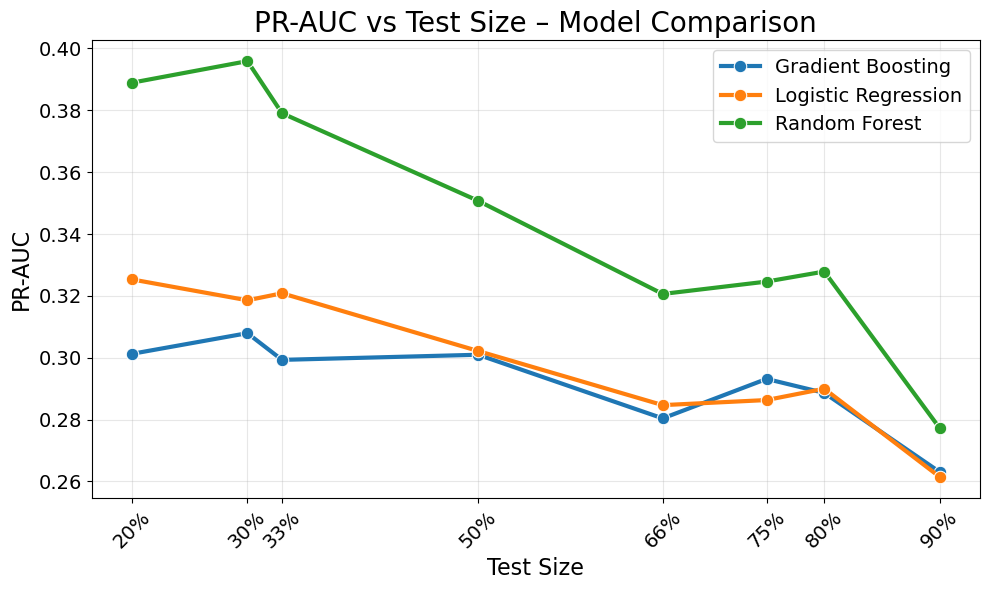

In [6]:
fig = compare_models(summary4, "PR-AUC")
fig

fig.savefig("images/4.supervised_pr_comparison.png", dpi=300, bbox_inches="tight")

## Accuracy

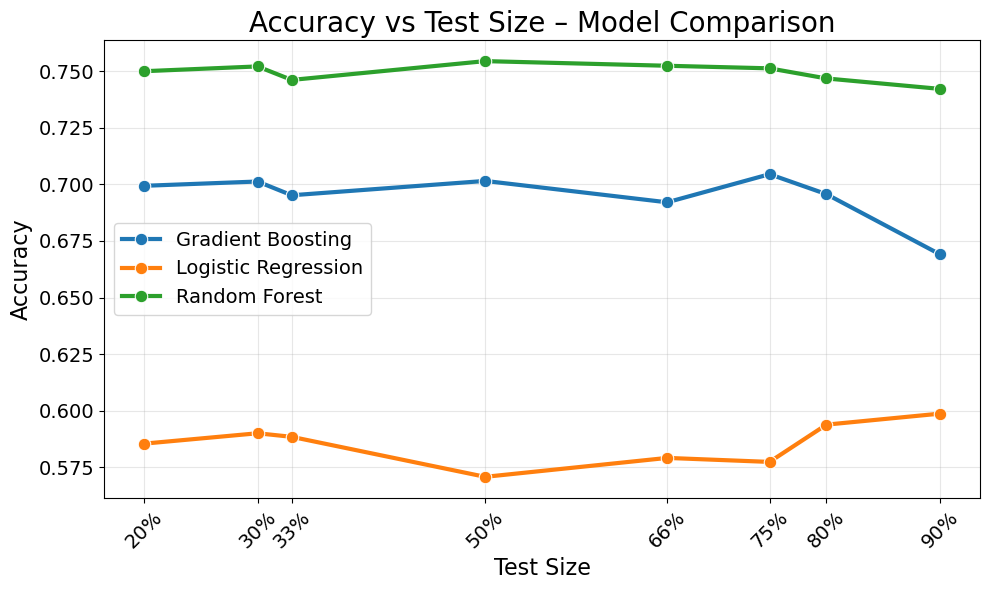

In [7]:
fig = compare_models(summary4, "Accuracy")
fig

fig.savefig("images/4.supervised_acc_comparison.png", dpi=300, bbox_inches="tight")

# Neural Network + Random Forest

Using $\texttt{5.nn\_rf}$.

In [8]:
df_2.head(3)

,model,random_state,test_size,n_epochs,batch_size,learning_rate,weight_decay,ROC-AUC,PR-AUC,Accuracy
0,NN+RF,42,0.3,50,16,0.0005,0.0001,0.609841,0.390447,0.728814
1,NN+RF,42,0.3,50,16,0.0005,0.0001,0.600542,0.363773,0.771186
2,NN+RF,42,0.3,50,16,0.0005,0.0001,0.633088,0.385839,0.754237


## Parameter decision

In [9]:
summary51 = (
    df_2
    .query("random_state == 42 and test_size == 0.3")
    .groupby(["batch_size", "weight_decay"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary51

,batch_size,weight_decay,ROC-AUC,PR-AUC,Accuracy
0,16,1.000000e-08,0.592755,0.372785,0.750847
1,16,1.000000e-04,0.631422,0.403200,0.755932
2,32,1.000000e-08,0.595893,0.383854,0.747458
3,32,1.000000e-04,0.588260,0.384888,0.742373


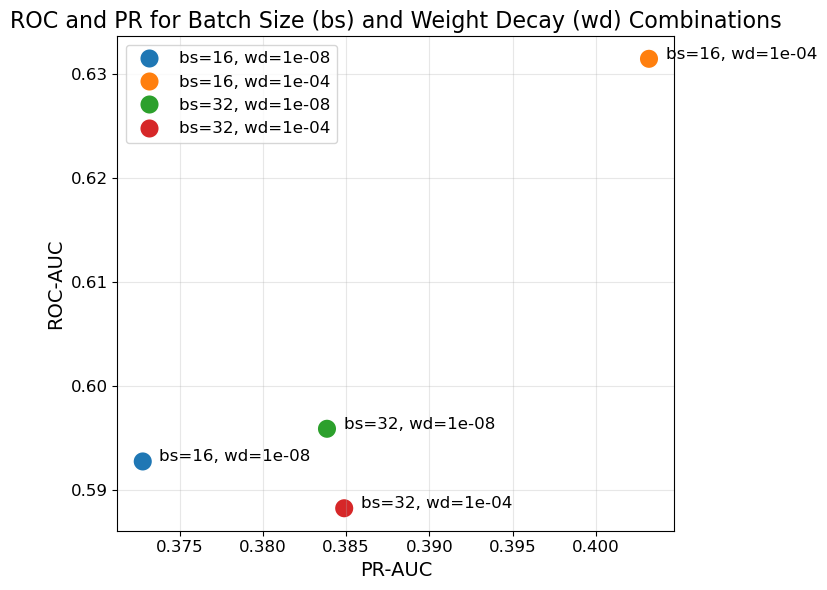

In [10]:
# Create a label for each configuration
summary51["label"] = summary51.apply(
    lambda row: f"bs={int(row['batch_size'])}, wd={row['weight_decay']:.0e}",
    axis=1
)

plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot(
    data=summary51, x="PR-AUC", y="ROC-AUC", s=200, hue="label", palette="tab10"
)

# Add text labels next to each point
for _, row in summary51.iterrows():
    plt.text( row["PR-AUC"] + 0.001, row["ROC-AUC"], row["label"], fontsize=12 )

plt.title("ROC and PR for Batch Size (bs) and Weight Decay (wd) Combinations", fontsize=16)
plt.xlabel("PR-AUC", fontsize=14)
plt.ylabel("ROC-AUC", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3)
plt.legend(fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("images/5.nn+rf_param_combination.png", dpi=300, bbox_inches="tight")
plt.show()

## Dataset

In [11]:
summary52 = (
    df_2
    .query("batch_size == 16 and weight_decay == 1e-4")
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary52

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,NN+RF,0.20,0.579130,0.352898,0.747363
1,NN+RF,0.30,0.573843,0.336671,0.744280
2,NN+RF,0.33,0.559431,0.329578,0.741346
3,NN+RF,0.50,0.536315,0.297068,0.723639
4,NN+RF,0.60,0.527297,0.280519,0.726950
5,NN+RF,0.66,0.520990,0.275647,0.734073
6,NN+RF,0.70,0.518825,0.273548,0.728254
7,NN+RF,0.75,0.529743,0.281156,0.734694
8,NN+RF,0.80,0.527515,0.279516,0.730298
9,NN+RF,0.90,0.499672,0.249409,0.703717


## ROC-AUC

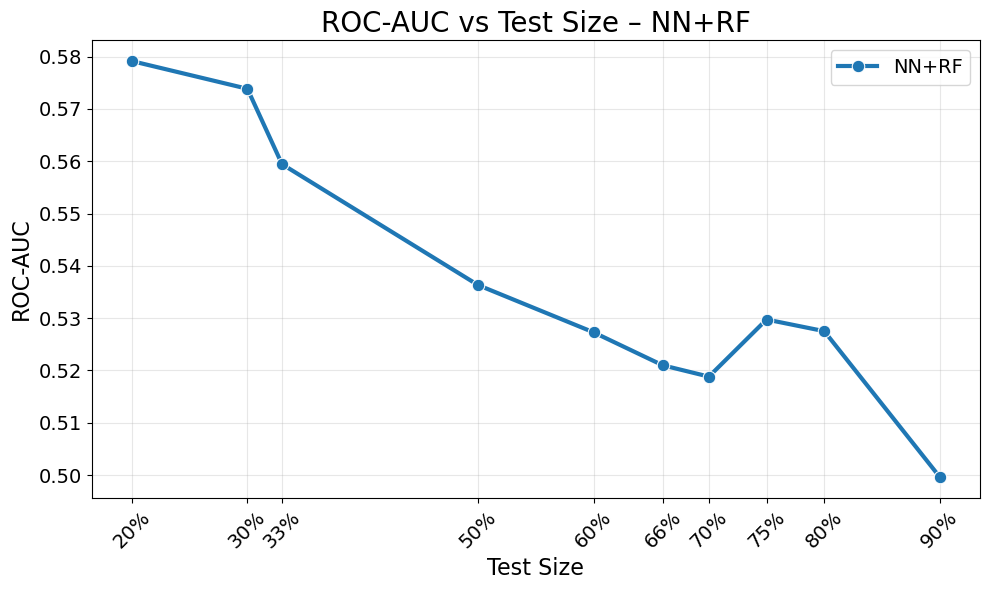

In [12]:
fig = compare_test_size(summary52, "ROC-AUC")
fig

fig.savefig("images/5.nn+rf_roc_results.png", dpi=300, bbox_inches="tight")

## PR-AUC

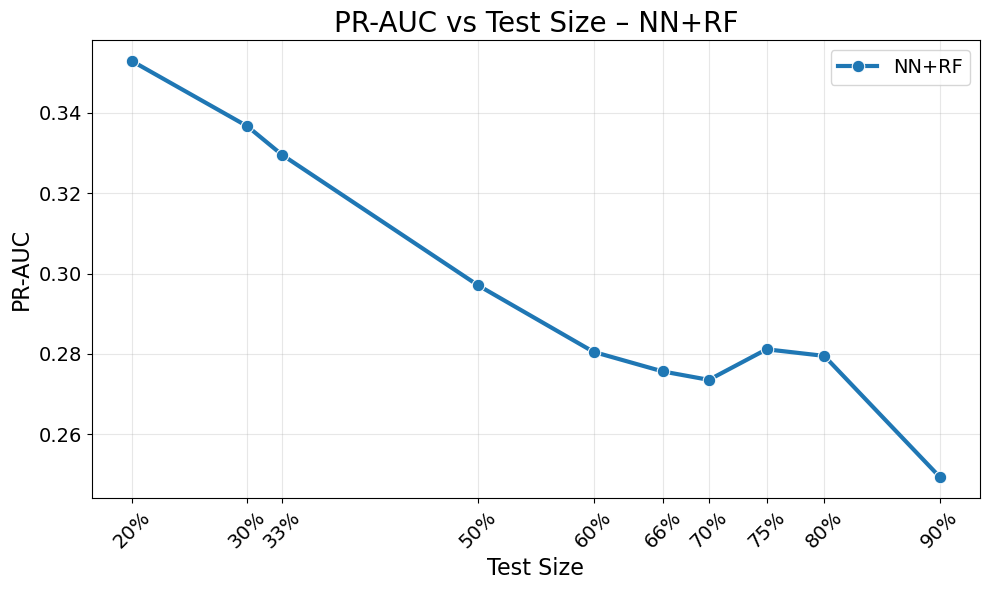

In [13]:
fig = compare_test_size(summary52, "PR-AUC")
fig

fig.savefig("images/5.nn+rf_pr_results.png", dpi=300, bbox_inches="tight")

## ROC + PR

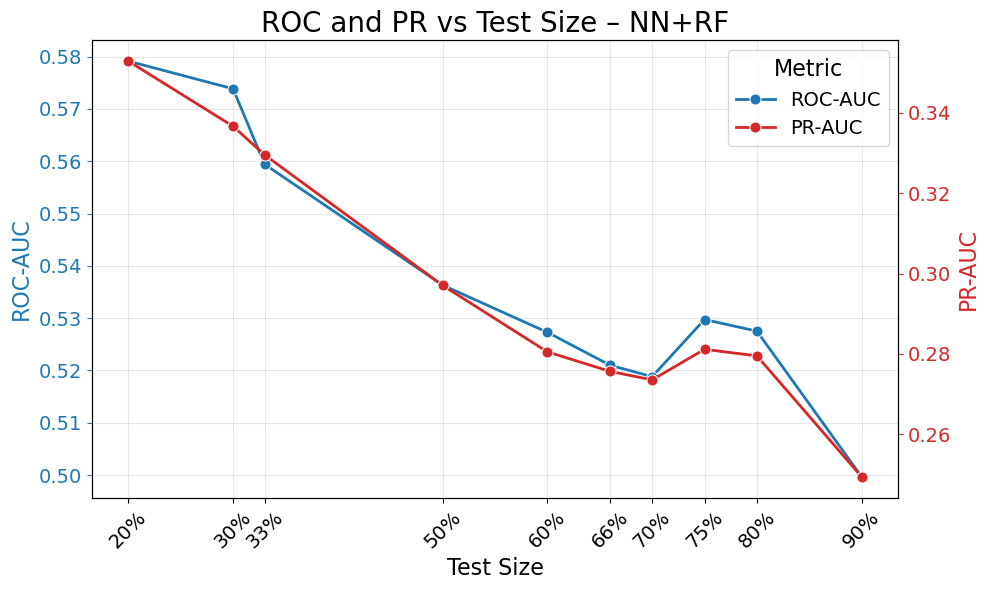

In [14]:
fig = roc_pr_combined(summary52)
fig

fig.savefig("images/5.nn+rf_roc_pr_combined.png", dpi=300, bbox_inches="tight")

## Accuracy

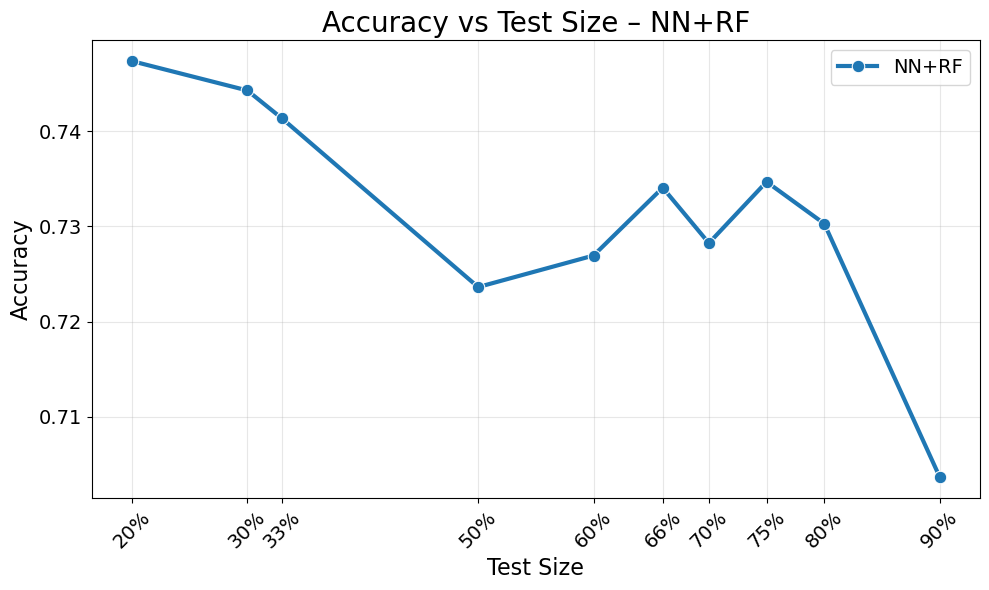

In [15]:
fig = compare_test_size(summary52, "Accuracy")
fig

fig.savefig("images/5.nn+rf_acc_results.png", dpi=300, bbox_inches="tight")

# Contrastive model

Using $\texttt{6\_contrastive}$

In [16]:
df_3.head(3)

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
0,Contrastive,42,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.603005,0.313736,0.710997
1,Contrastive,42,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.559104,0.274763,0.695652
2,Contrastive,42,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.543030,0.284790,0.698210


## Parameter decision

In [17]:
summary61 = (
    df_3
    .query("test_size == 0.2")
    .groupby(["test_size", "margin"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary61

,test_size,margin,ROC-AUC,PR-AUC,Accuracy
0,0.2,0.2,0.560017,0.293963,0.689898
1,0.2,0.3,0.568697,0.297625,0.695062
2,0.2,0.4,0.550747,0.289172,0.694054


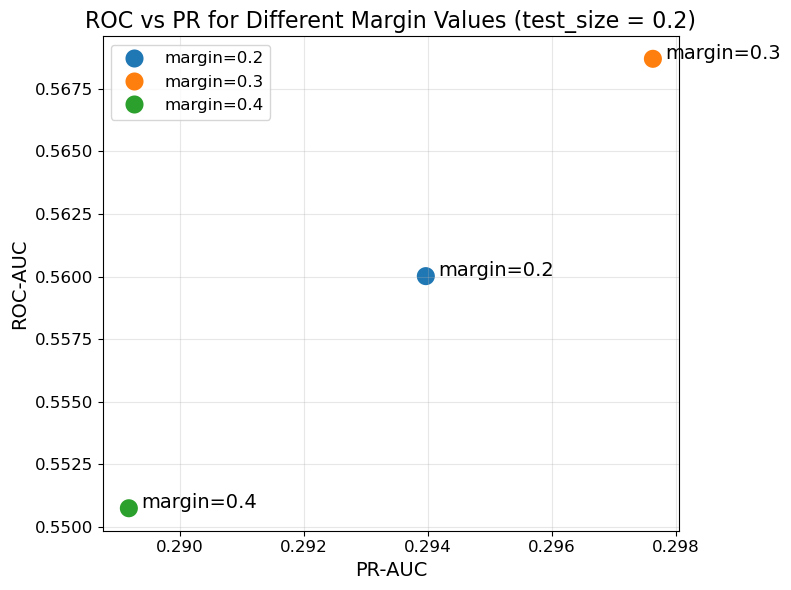

In [18]:
summary61["label"] = summary61.apply(
    lambda row: f"margin={row['margin']}",
    axis=1
)

plt.figure(figsize=(8, 6))

sns.scatterplot( data=summary61, x="PR-AUC", y="ROC-AUC", s=200, hue="label", palette="tab10" )

# Add text labels next to each point
for _, row in summary61.iterrows():
    plt.text( row["PR-AUC"] + 0.0002, row["ROC-AUC"], row["label"], fontsize=14 )

plt.title("ROC vs PR for Different Margin Values (test_size = 0.2)", fontsize=16)
plt.xlabel("PR-AUC", fontsize=14)
plt.ylabel("ROC-AUC", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3)
plt.legend(fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("images/6.contrastive_margin_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Dataset

In [19]:
summary62 = (
    df_3
    .query("margin == 0.3")
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary62

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Contrastive,0.20,0.568697,0.297625,0.695062
1,Contrastive,0.33,0.571141,0.291619,0.685422
2,Contrastive,0.50,0.589621,0.316138,0.708133
3,Contrastive,0.66,0.558374,0.288125,0.691869
4,Contrastive,0.75,0.551755,0.280116,0.694800
5,Contrastive,0.80,0.551119,0.276442,0.687500
6,Contrastive,0.90,0.547233,0.275663,0.692964


## ROC-AUC

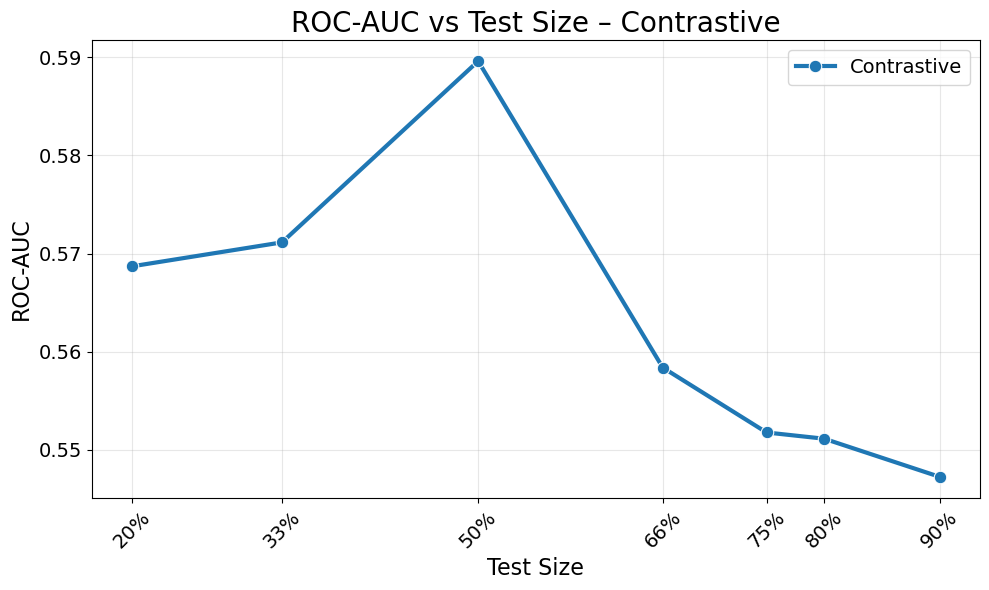

In [20]:
fig = compare_test_size(summary62, "ROC-AUC")
fig

fig.savefig("images/6.contrastive_roc_results.png", dpi=300, bbox_inches="tight")

## PR-AUC

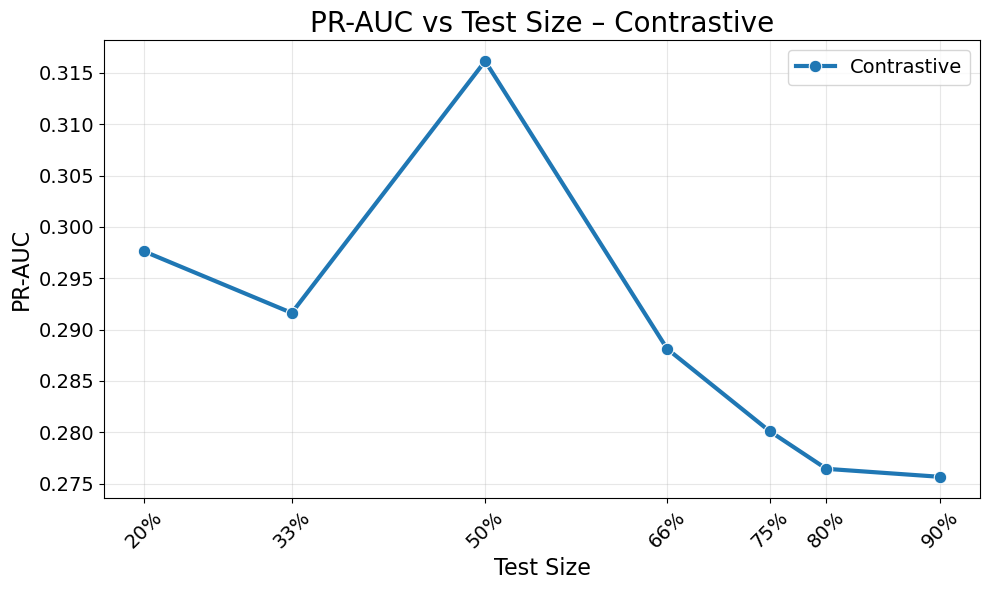

In [21]:
fig = compare_test_size(summary62, "PR-AUC")
fig

fig.savefig("images/6.contrastive_pr_results.png", dpi=300, bbox_inches="tight")

## ROC + PR

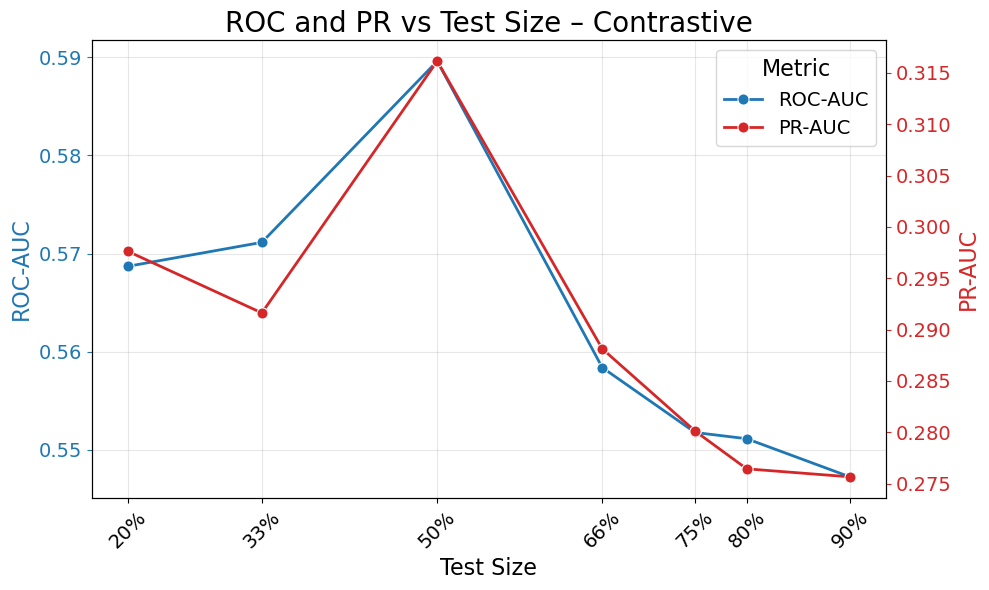

In [22]:
fig = roc_pr_combined(summary62)
fig

fig.savefig("images/6.contrastive_roc_pr_combined.png", dpi=300, bbox_inches="tight")

## Accuracy

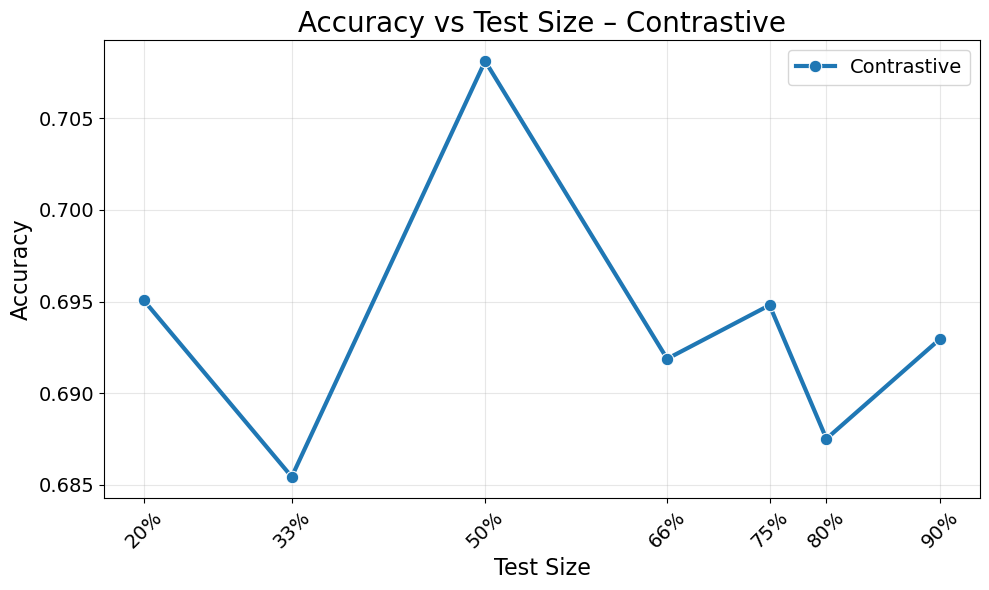

In [23]:
fig = compare_test_size(summary62, "Accuracy")
fig

fig.savefig("images/6.contrastive_acc_results.png", dpi=300, bbox_inches="tight")

# Contrastive model + Gating

Using $\texttt{7.contrastive\_gating}$.

In [24]:
df_4.head(3)

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,lambda_l1,ROC-AUC,PR-AUC,Accuracy,n_layers
0,Contrastive+Gating,0,0.25,220,0.3,32,0.0001,1.000000e-08,300,0.01,0.1,0.536451,0.273388,0.703325,2
1,Contrastive+Gating,0,0.25,220,0.3,32,0.0005,1.000000e-08,300,0.01,0.1,0.558499,0.290982,0.652174,2
2,Contrastive+Gating,0,0.25,220,0.3,32,0.0005,1.000000e-08,300,0.01,0.2,0.560242,0.274870,0.677749,2


## Parameter decision

In [25]:
summary71 = (
    df_4
    .query("model == 'Contrastive+Gating' and n_layers == 1")
    .groupby(["learning_rate", "lambda_l1"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary71

,learning_rate,lambda_l1,ROC-AUC,PR-AUC,Accuracy
0,0.0005,0.05,0.553880,0.287666,0.689003
1,0.0005,0.10,0.547799,0.277992,0.673657
2,0.0005,0.20,0.556120,0.290853,0.688491
3,0.0010,0.05,0.568094,0.312953,0.686957
4,0.0010,0.10,0.580605,0.310396,0.698210
5,0.0010,0.20,0.566817,0.303530,0.699233


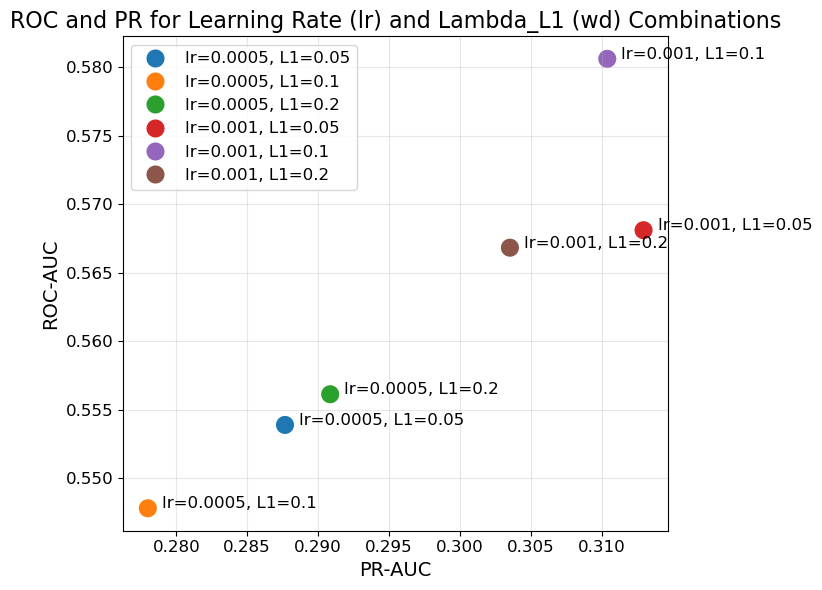

In [26]:
# Create a label for each configuration
summary71["label"] = summary71.apply(
    lambda row: f"lr={row['learning_rate']}, L1={row['lambda_l1']}",
    axis=1
)

plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot( data=summary71, x="PR-AUC", y="ROC-AUC", s=200, hue="label", palette="tab10" )

# Add text labels next to each point
for _, row in summary71.iterrows():
    plt.text( row["PR-AUC"] + 0.001, row["ROC-AUC"], row["label"], fontsize=12 )

plt.title("ROC and PR for Learning Rate (lr) and Lambda_L1 (wd) Combinations", fontsize=16)
plt.xlabel("PR-AUC", fontsize=14)
plt.ylabel("ROC-AUC", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3)
plt.legend(fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("images/7.gating_param_combination.png", dpi=300, bbox_inches="tight")
plt.show()

## Dataset

In [27]:
summary72 = (
    df_4
    .query("model == 'Contrastive+Gating' and n_layers == 1 and learning_rate == 0.001 and lambda_l1 == 0.1")
    .groupby(["model", "test_size", "learning_rate", "lambda_l1"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary72

,model,test_size,learning_rate,lambda_l1,ROC-AUC,PR-AUC,Accuracy
0,Contrastive+Gating,0.25,0.001,0.1,0.580605,0.310396,0.69821


## Final weights

Using $\texttt{7.final\_weights}$.

In [28]:
df_5.head()

,learning_rate,weight_decay,lambda_l1,n_epochs,n_layers,margin,test_size,feature,avg_weight
0,0.001,1.000000e-08,0.1,100,1,0.3,0.25,arterial_hypertension,0.083516
1,0.001,1.000000e-08,0.1,100,1,0.3,0.25,pTNM_stage,0.081825
2,0.001,1.000000e-08,0.1,100,1,0.3,0.25,tobacco_use_Active smoker,0.080749
3,0.001,1.000000e-08,0.1,100,1,0.3,0.25,tumor_surgically_removed,0.080219
4,0.001,1.000000e-08,0.1,100,1,0.3,0.25,performance_status,0.079078


### Dataset

In [29]:
grouped = (
    df_5
    .groupby(["feature", "lambda_l1"])["avg_weight"]
    .mean()
    .reset_index()
)

t01 = grouped[grouped["lambda_l1"] == 0.1][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

t02 = grouped[grouped["lambda_l1"] == 0.2][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

t03 = grouped[grouped["lambda_l1"] == 0.05][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

final_table = pd.concat(
    [
        t01.rename(columns={"feature": "feature_0.1", "avg_weight": "avg_weight_0.1"}),
        t02.rename(columns={"feature": "feature_0.2", "avg_weight": "avg_weight_0.2"}),
        t03.rename(columns={"feature": "feature_0.05", "avg_weight": "avg_weight_0.05"})
    ],
    axis=1
)

final_table

,feature_0.1,avg_weight_0.1,feature_0.2,avg_weight_0.2,feature_0.05,avg_weight_0.05
0,sex,0.083789,sex,0.034779,sex,0.193284
1,pTNM_stage,0.076199,pTNM_stage,0.030337,performance_status,0.189436
2,performance_status,0.075876,bmi,0.029579,primary_tumor_Colorectal,0.185204
3,bmi,0.073216,grade_histological_differentiation,0.029332,pTNM_stage,0.184539
4,primary_tumor_Colorectal,0.073175,tobacco_use_Active smoker,0.028430,grade_histological_differentiation,0.177887
5,tobacco_use_Former smoker,0.070768,rs2227631_n_risk_alleles,0.027315,primary_tumor_Pancreatic,0.169110
6,arterial_hypertension,0.070513,previous_ate,0.027231,bmi,0.167068
7,rs169713_n_risk_alleles,0.069888,rs169713_n_risk_alleles,0.027035,rs2227631_n_risk_alleles,0.166272
8,tobacco_use_Active smoker,0.069839,performance_status,0.026995,catheter_device,0.166173
9,tobacco_use_Never has smoked,0.069397,tumor_surgically_removed,0.026840,tobacco_use_Active smoker,0.164453


#### Rank–Rank Scatterplots (pairwise comparisons)

In [30]:
# Extract ranking tables for each lambda
r01 = t01.copy()
r01["rank_0.1"] = r01.index + 1

r02 = t02.copy()
r02["rank_0.2"] = r02.index + 1

r03 = t03.copy()
r03["rank_0.05"] = r03.index + 1

In [31]:
# Merge on feature name
rankings = (
    r01[["feature", "rank_0.1"]]
    .merge(r02[["feature", "rank_0.2"]], on="feature")
    .merge(r03[["feature", "rank_0.05"]], on="feature")
)

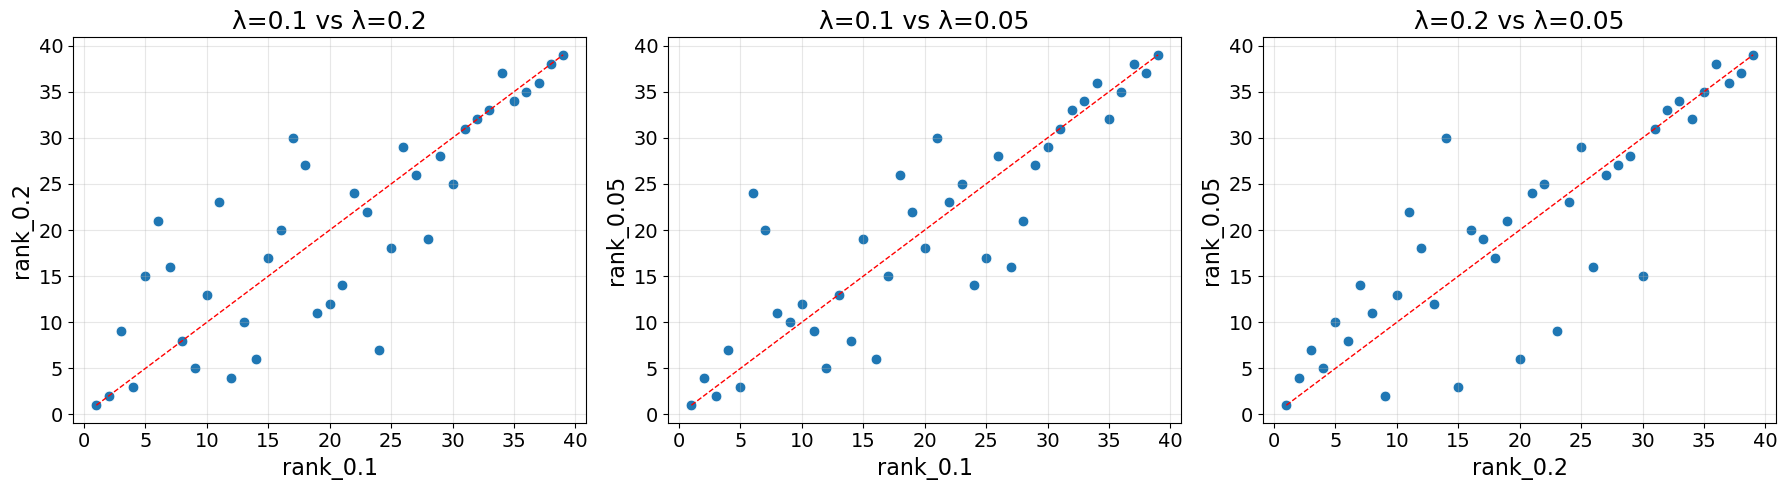

In [32]:
pairs = [
    ("rank_0.1", "rank_0.2", "λ=0.1 vs λ=0.2"),
    ("rank_0.1", "rank_0.05", "λ=0.1 vs λ=0.05"),
    ("rank_0.2", "rank_0.05", "λ=0.2 vs λ=0.05"),
]

plt.figure(figsize=(18, 5))

for i, (xcol, ycol, title) in enumerate(pairs, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(
        data=rankings,
        x=xcol,
        y=ycol,
        s=60
    )
    
    # Diagonal reference line
    max_rank = rankings[[xcol, ycol]].values.max()
    plt.plot([1, max_rank], [1, max_rank], color="red", linestyle="--", linewidth=1)
    
    plt.title(title, fontsize=18)
    plt.xlabel(xcol, fontsize=16)
    plt.ylabel(ycol, fontsize=16)
    
    # Bigger tick labels
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("images/7.final_weights_scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

#### Spearman Correlation Heatmap of Rankings

In [33]:
# correlation matrix

corr = rankings[["rank_0.1", "rank_0.2", "rank_0.05"]].corr(method="spearman")
corr

,rank_0.1,rank_0.2,rank_0.05
rank_0.1,1.000000,0.831174,0.872672
rank_0.2,0.831174,1.000000,0.846559
rank_0.05,0.872672,0.846559,1.000000


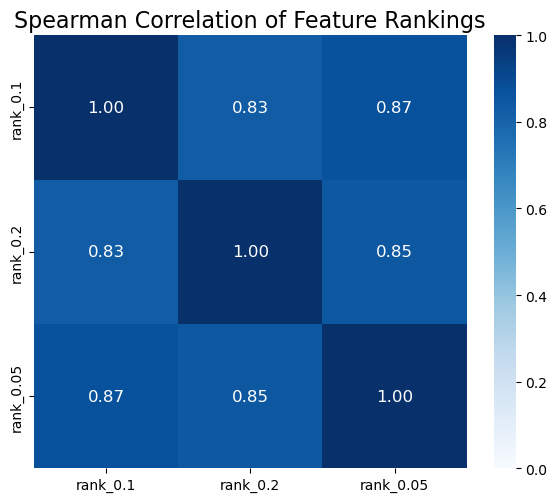

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    fmt=".2f",
    annot_kws={"fontsize": 12}
)

plt.title("Spearman Correlation of Feature Rankings", fontsize=16)

plt.tight_layout()
plt.savefig("images/7.final_weights_spearmam.png", dpi=300, bbox_inches="tight")
plt.show()

Feature importance is robust to $\lambda_{L1}$.

# Contrastive after gating

Using $\texttt{8.contrastive\_after\_gating}$.

In [35]:
df_6.head(3)

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
0,Contrastive After Gating,0,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.588958,0.298031,0.682864
1,Contrastive After Gating,1,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.579872,0.334629,0.703325
2,Contrastive After Gating,2,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.605334,0.308648,0.708440


## Dataset

In [36]:
summary80 = (
    df_6
    .groupby(["model", "batch_size", "weight_decay", "learning_rate", "margin", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary80

,model,batch_size,weight_decay,learning_rate,margin,test_size,ROC-AUC,PR-AUC,Accuracy
0,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.20,0.597515,0.324823,0.708760
1,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.33,0.598011,0.319965,0.709399
2,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.50,0.605343,0.327443,0.713555
3,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.66,0.581059,0.301831,0.706841
4,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.75,0.567383,0.293038,0.707268
5,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.80,0.564368,0.287099,0.695093
6,Contrastive After Gating,32,1.000000e-08,0.0005,0.3,0.90,0.553402,0.279900,0.700645


In [37]:
summary8 = (
    df_6
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary8

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Contrastive After Gating,0.20,0.597515,0.324823,0.708760
1,Contrastive After Gating,0.33,0.598011,0.319965,0.709399
2,Contrastive After Gating,0.50,0.605343,0.327443,0.713555
3,Contrastive After Gating,0.66,0.581059,0.301831,0.706841
4,Contrastive After Gating,0.75,0.567383,0.293038,0.707268
5,Contrastive After Gating,0.80,0.564368,0.287099,0.695093
6,Contrastive After Gating,0.90,0.553402,0.279900,0.700645


## ROC-AUC

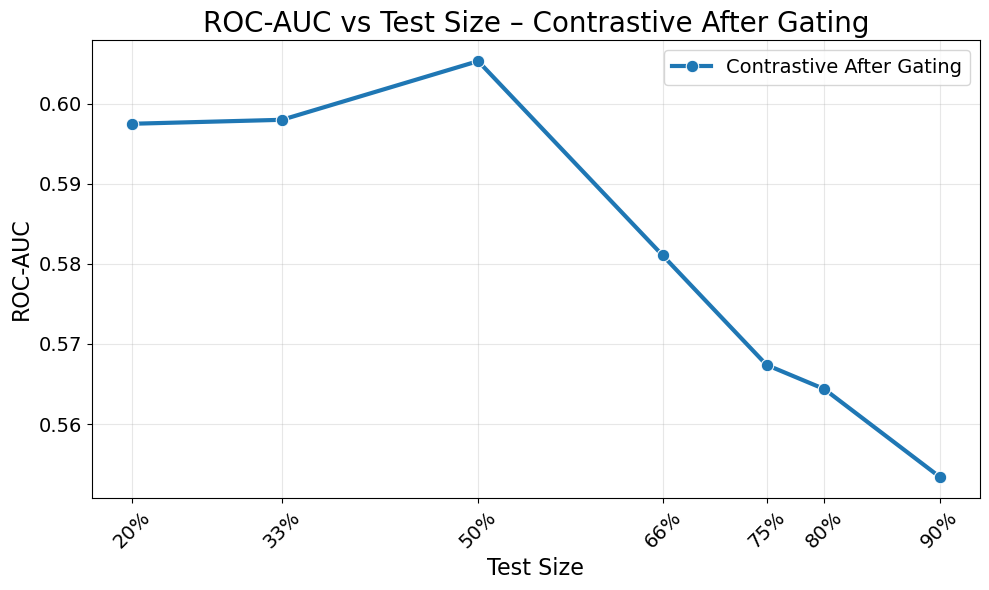

In [38]:
fig = compare_test_size(summary8, "ROC-AUC")
fig

fig.savefig("images/8.post_gating_roc_results.png", dpi=300, bbox_inches="tight")

## PR-AUC

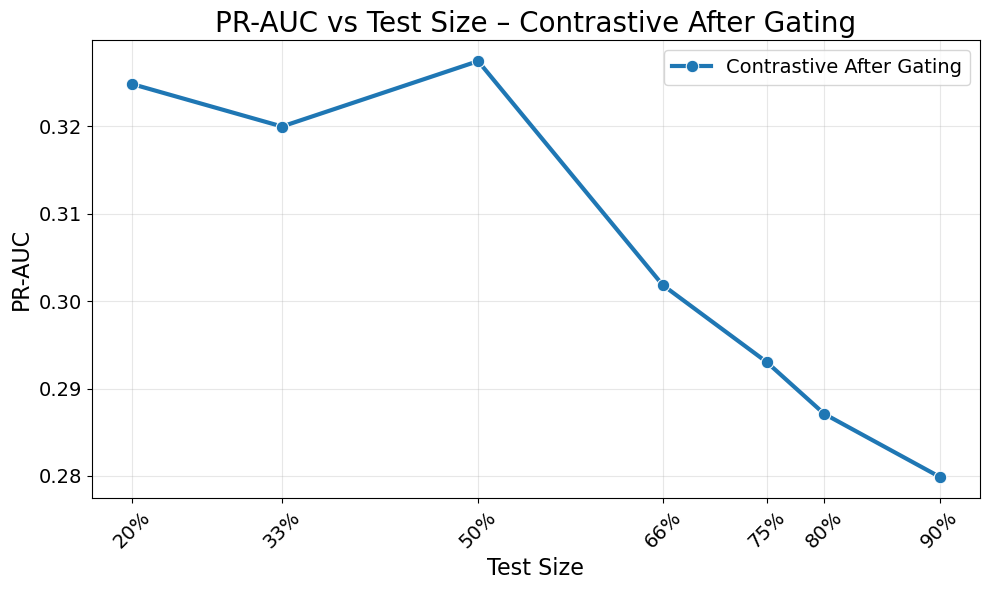

In [39]:
fig = compare_test_size(summary8, "PR-AUC")
fig

fig.savefig("images/8.post_gating_pr_results.png", dpi=300, bbox_inches="tight")

## ROC + PR

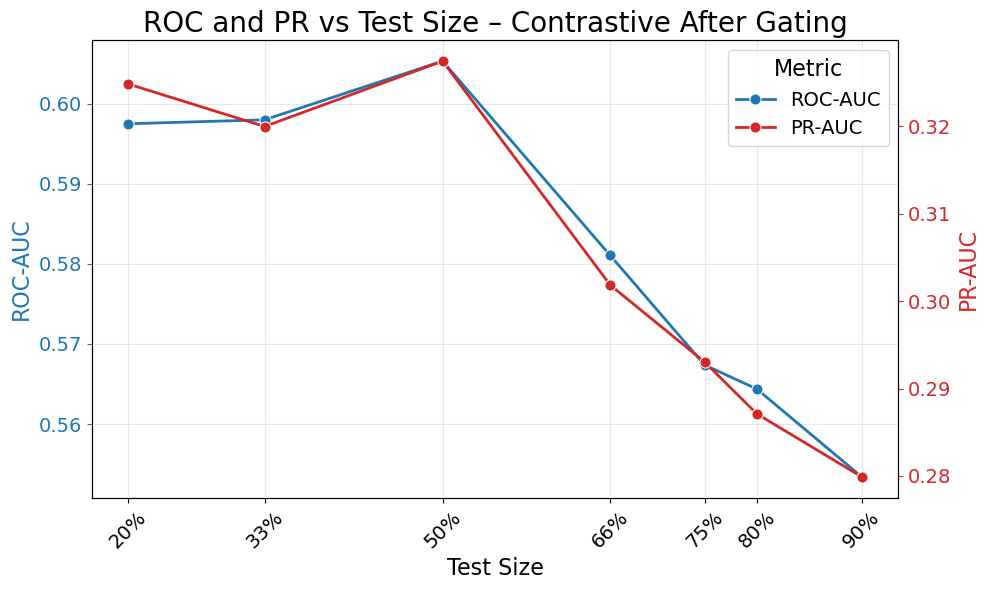

In [40]:
fig = roc_pr_combined(summary8)
fig

fig.savefig("images/8.post_gating_roc_pr_results.png", dpi=300, bbox_inches="tight")

## Accuracy

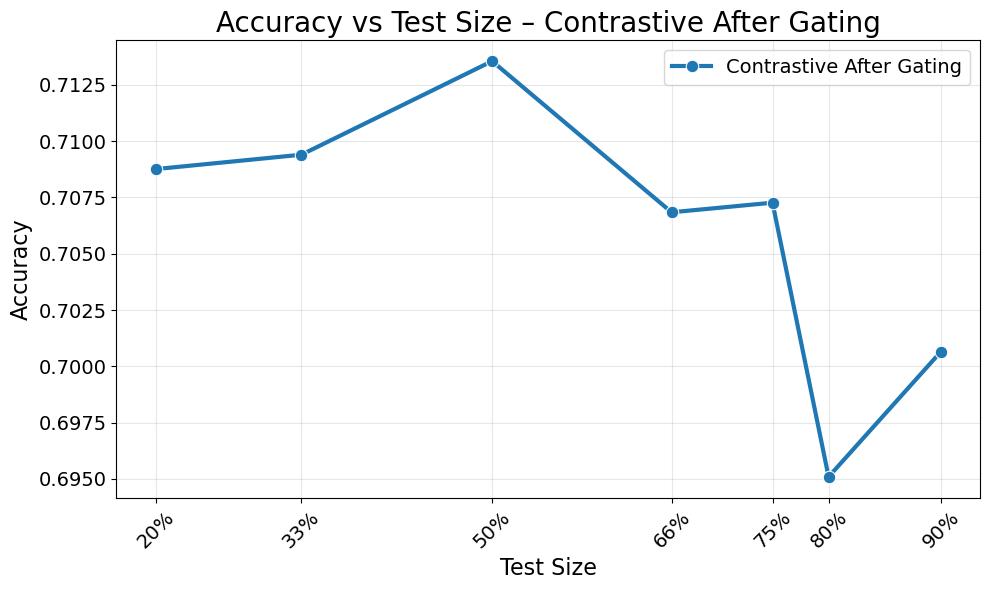

In [41]:
fig = compare_test_size(summary8, "Accuracy")
fig

fig.savefig("images/8.post_gating_acc_results.png", dpi=300, bbox_inches="tight")

# Final comparison: contrastive and gating effects

## Contrastive effect

In [42]:
summary_combined_1 = pd.concat([summary52, summary62], ignore_index=True)

### ROC-AUC

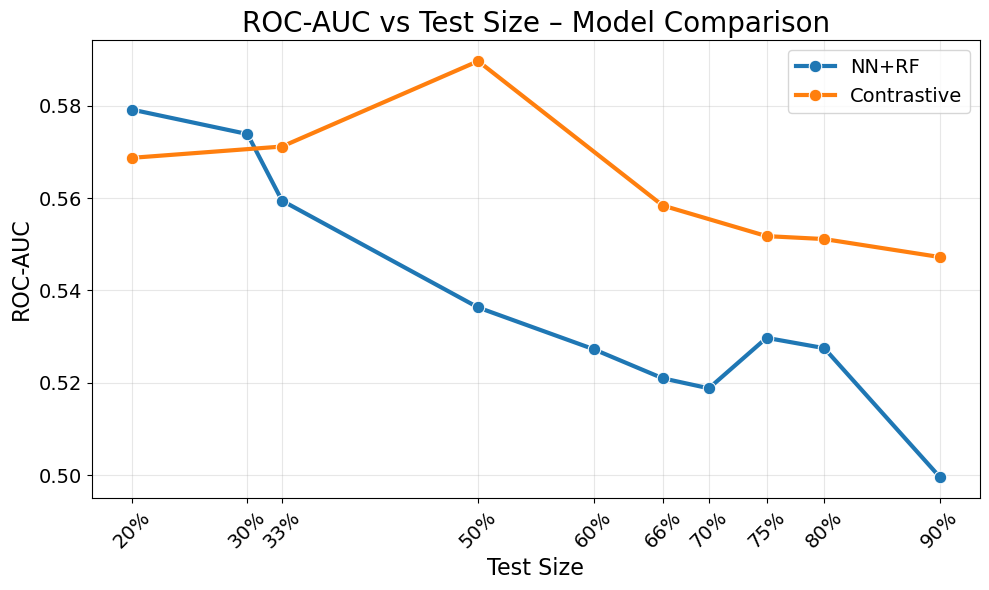

In [43]:
fig = compare_models(summary_combined_1, "ROC-AUC")
fig

fig.savefig("images/0.nn_contr_roc_comparison.png", dpi=300, bbox_inches="tight")

### PR-AUC

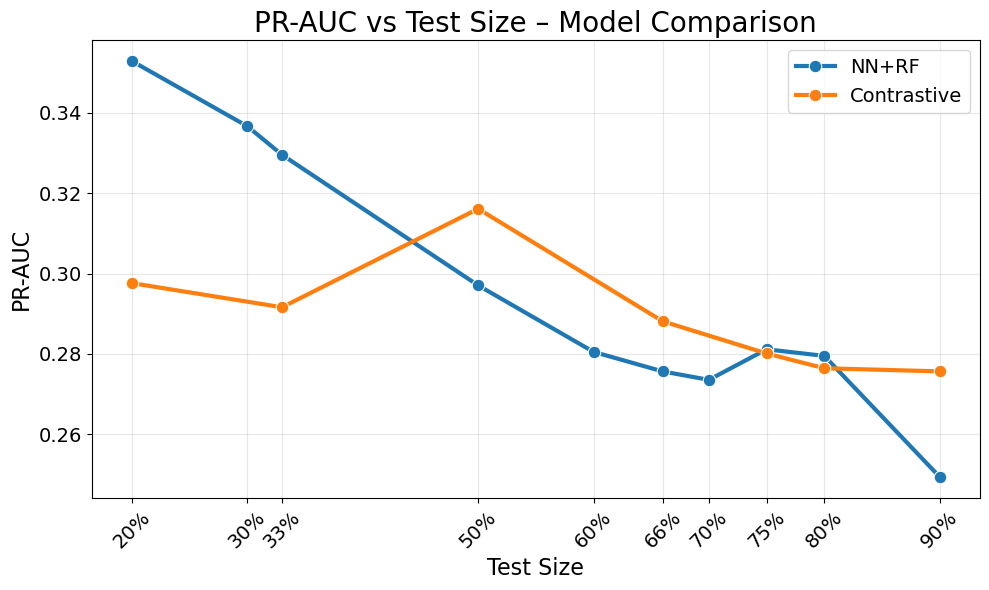

In [44]:
fig = compare_models(summary_combined_1, "PR-AUC")
fig

fig.savefig("images/0.nn_contr_pr_comparison.png", dpi=300, bbox_inches="tight")

### Accuracy

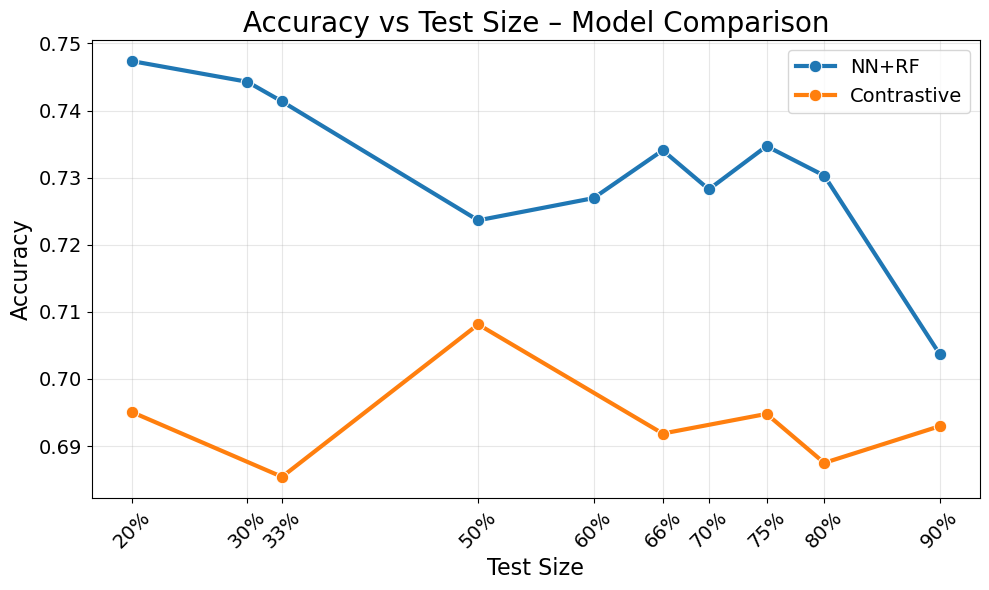

In [45]:
fig = compare_models(summary_combined_1, "Accuracy")
fig

fig.savefig("images/0.nn_contr_acc_comparison.png", dpi=300, bbox_inches="tight")

## Gating effect

In [46]:
summary_combined2 = pd.concat([summary62, summary8], ignore_index=True)

### ROC-AUC

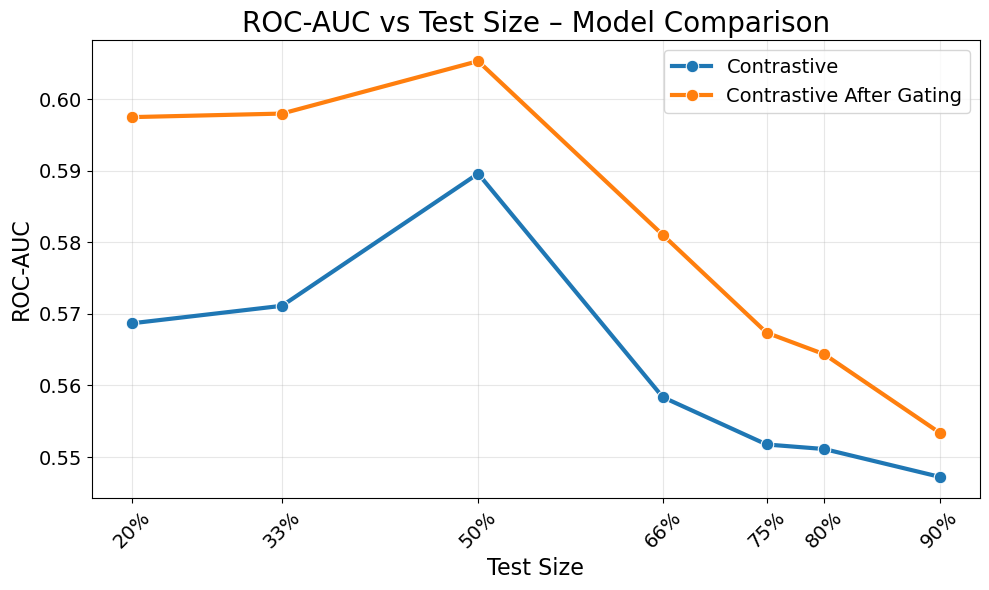

In [47]:
fig = compare_models(summary_combined2, "ROC-AUC")
fig

fig.savefig("images/0.contr_gating_roc_comparison.png", dpi=300, bbox_inches="tight")

### PR-AUC

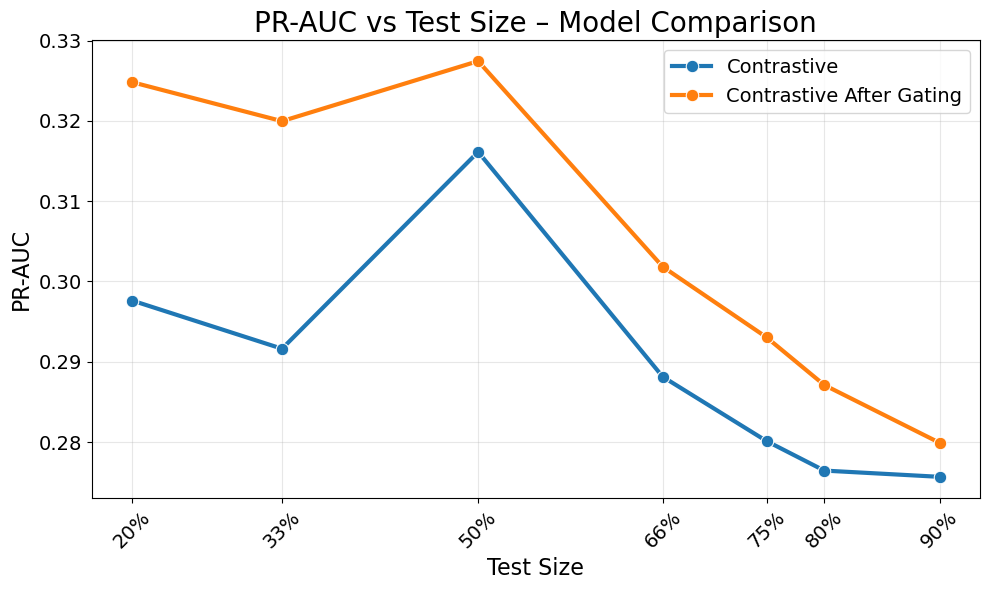

In [48]:
fig = compare_models(summary_combined2, "PR-AUC")
fig

fig.savefig("images/0.contr_gating_pr_comparison.png", dpi=300, bbox_inches="tight")

### Accuracy

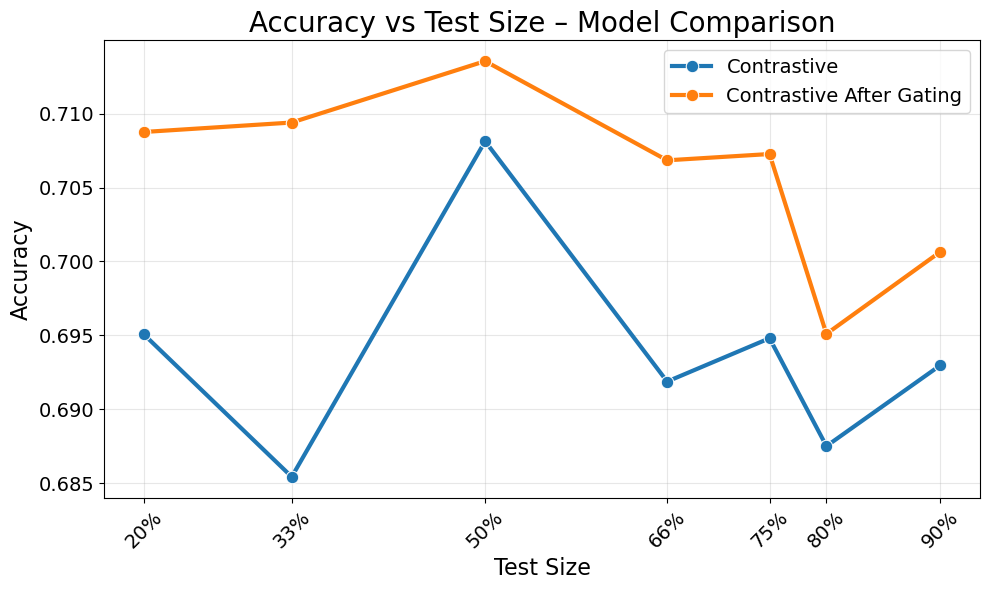

In [49]:
fig = compare_models(summary_combined2, "Accuracy")
fig

fig.savefig("images/0.contr_gating_acc_comparison.png", dpi=300, bbox_inches="tight")

## Overall

In [50]:
summary_combined3 = pd.concat([summary52, summary62, summary8], ignore_index=True)

### ROC-AUC

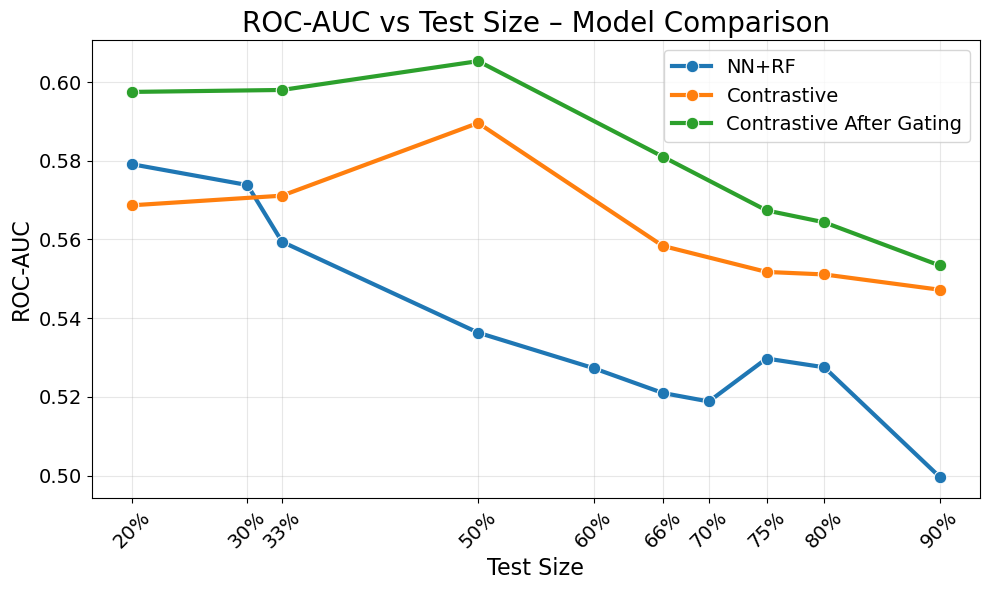

In [51]:
fig = compare_models(summary_combined3, "ROC-AUC")
fig

fig.savefig("images/0.overall_roc_comparison.png", dpi=300, bbox_inches="tight")

### PR-AUC

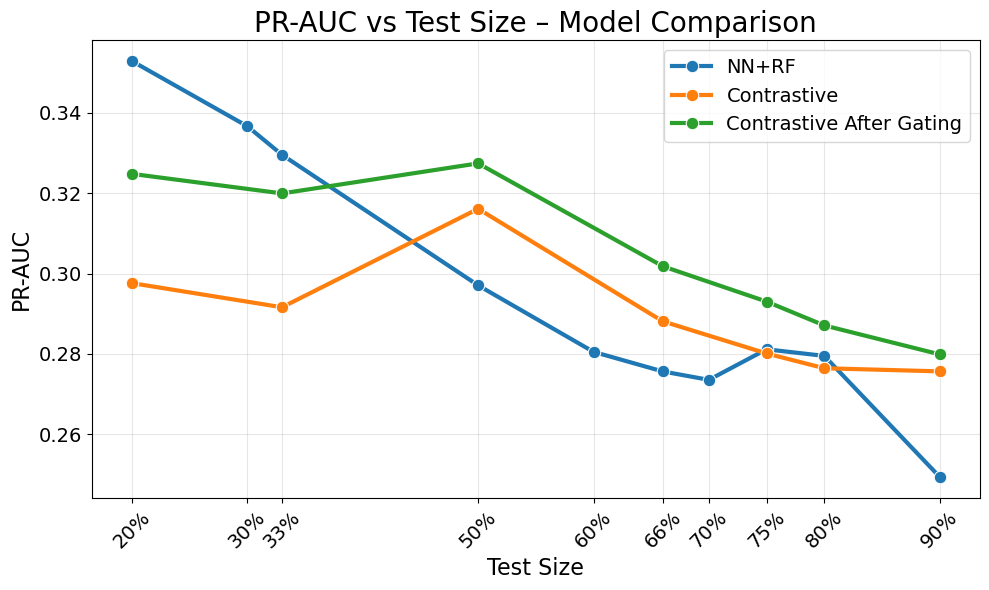

In [52]:
fig = compare_models(summary_combined3, "PR-AUC")
fig

fig.savefig("images/0.overall_pr_comparison.png", dpi=300, bbox_inches="tight")

### Accuracy

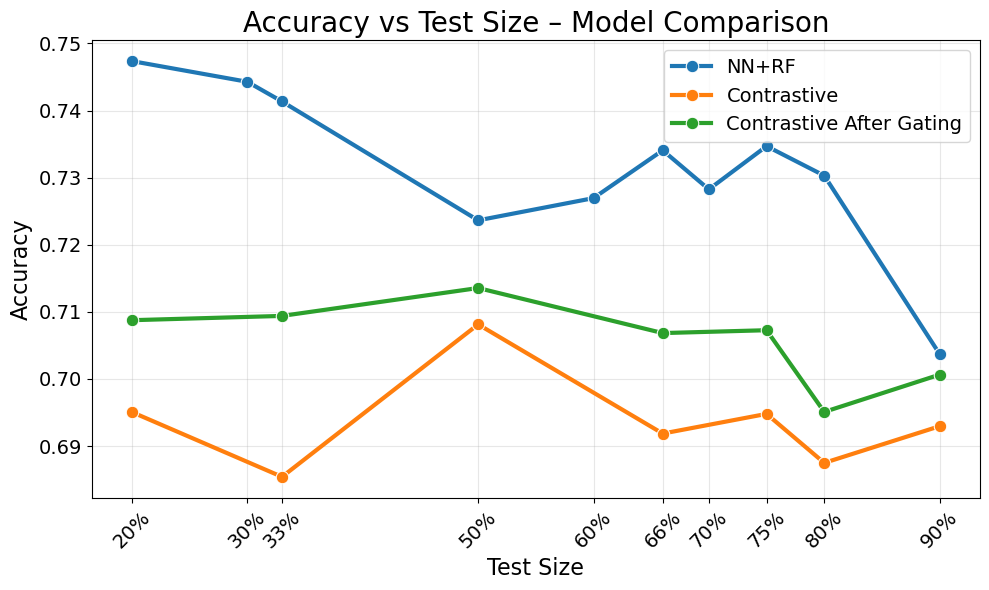

In [53]:
fig = compare_models(summary_combined3, "Accuracy")
fig

fig.savefig("images/0.overall_acc_comparison.png", dpi=300, bbox_inches="tight")

# Synthetic dataset - gating effect

## Dataset

In [54]:
df_7.head(3)

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
0,Contrastive,0,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.577024,0.306672,0.693095
1,Contrastive,5,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.543626,0.304391,0.693095
2,Contrastive,42,0.2,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.488178,0.299732,0.675192


In [55]:
summary7 = (
    df_7
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary7

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Contrastive,0.20,0.536276,0.303598,0.687127
1,Contrastive,0.33,0.541302,0.312035,0.691390
2,Contrastive,0.50,0.540624,0.292707,0.670077
3,Contrastive,0.66,0.508552,0.278851,0.672634
4,Contrastive,0.75,0.526297,0.285104,0.682864
5,Contrastive,0.90,0.513017,0.269123,0.668751


In [56]:
df_8.head(3)

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
0,Contrastive After Gating,0,0.9,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.531483,0.291246,0.684854
1,Contrastive After Gating,5,0.9,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.495835,0.261632,0.643933
2,Contrastive After Gating,42,0.9,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.507484,0.258653,0.662404


In [57]:
summary8 = (
    df_8
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary8

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Contrastive After Gating,0.20,0.511766,0.284443,0.667519
1,Contrastive After Gating,0.33,0.541658,0.305825,0.676044
2,Contrastive After Gating,0.50,0.511851,0.287795,0.685422
3,Contrastive After Gating,0.66,0.524011,0.282459,0.682864
4,Contrastive After Gating,0.75,0.518284,0.279890,0.682296
5,Contrastive After Gating,0.90,0.511601,0.270511,0.663730


In [58]:
summary_synthetic = pd.concat([summary7, summary8], ignore_index=True)

## ROC-AUC

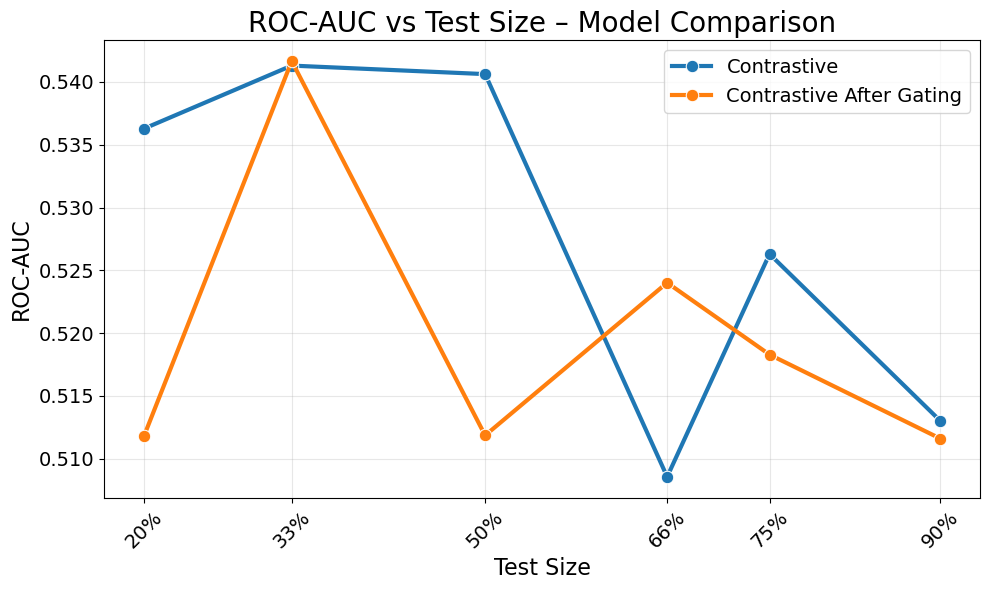

In [59]:
fig = compare_models(summary_synthetic, "ROC-AUC")
fig

fig.savefig("images/synthetic_roc_comparison.png", dpi=300, bbox_inches="tight")

## PR-AUC

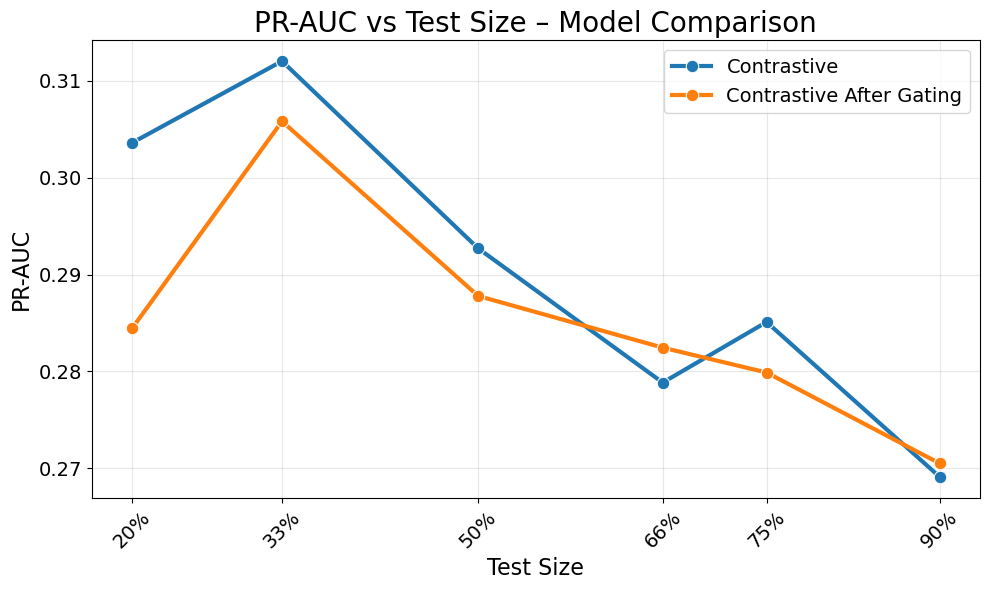

In [60]:
fig = compare_models(summary_synthetic, "PR-AUC")
fig

fig.savefig("images/synthetic_pr_comparison.png", dpi=300, bbox_inches="tight")